<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/banner_IA.png"  width="1000px" height="250px">

# <center>**10. Machine Learning: Additional Methods**</center>

This notebook surveys classical supervised learning models for **classification**: how they are trained, how performance is estimated, and how their **decision boundaries** behave on toy and tabular data.

## **Outline**

1. [**Decision Trees (DT)**](#eje1)
2. [**Random Forest (RF)**](#eje2)
3. [**Support Vector Machine (SVM)**](#eje3)
4. [**Classification Boundaries**](#topic4)
5. [**Overfitting and Underfitting**](#topic5)


In [18]:
#@title **Execute this cell**
#@markdown Please include your student id
import sys
import inspect

group_id = "IA1-20261-C2" #@param {type:"string"}
assignment_id = group_id +'.machine_learning_methods'
student_id = "2225001" #@param {type:"string"}
"""
Put your student ID here

Example: student_id =  '2152145'
"""

"\nPut your student ID here\n\nExample: student_id =  '2152145'\n"

In [19]:
#@title **Execute this cell**
#@markdown **UTILS**
#@markdown Please dont modify any line in this cell

import os
import json
import requests
from collections import namedtuple


Config = namedtuple('Config', ['server_name'])
config = Config(server_name='https://bivlabgrader.azurewebsites.net/api')


def check_solution_and_evaluate(assignment_id: str, student_func_str: str):

    # Set the endpoint and payload.
    payload = {
        'func_str': student_func_str,
        'assignment_id': assignment_id,
        'student_id': student_id
    }
    endpoint_url = config.server_name + '/CheckAndEvaluateSolution'
    # print(endpoint_url)

    # Make request to server with the data coming from the notebook.
    r = requests.post(endpoint_url, params=payload)
    pprint_json_response(r.json())
    return r


def pprint_json_response(response, indent=0):
    """Pretty print the response."""
    for key, value in response.items():
        print('\t' * indent + str(key.capitalize()))

        # If dictionary, do a recurrent call.
        if isinstance(value, dict):
            pprint_json_response(value, indent + 1)
        else:
            # Enumerate elements if list.
            if isinstance(value, list):
                if len(value) == 1:
                    print('\t' * (indent + 1) + str(value[0]))
                else:
                    for i, e in enumerate(value, start=1):
                        print('\t' * (indent + 1) + f'{i}. {e}')
            else:
                print('\t' * (indent + 1) + str(value))

In [3]:
#@title **MONTAR EL DRIVE** { display-mode: "form" }
import os
from google.colab import drive

path_ai = "IA-1-UIS" #@param {type:"string"}
path = "/content/drive/My Drive/" + path_ai
drive.mount('/content/drive')
os.chdir(path)
print(os.getcwd())

Mounted at /content/drive
/content/drive/My Drive/IA-1-UIS


In [4]:
#@title **Load libs** { display-mode: "form" }
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
pd.__version__

'2.2.2'

## About this notebook

**What it does.** You will train and compare several **classification** estimators from scikit-learn on a small tabular dataset (banknote authentication) with a fixed **train–test split**, and you will relate **cross-validation scores**, **precision–recall**, **feature importances**, and **2D decision boundaries** to each model’s inductive bias.

**Problem setting.** Given input features, predict a **binary** label. The focus is not a single accuracy number but **how each algorithm carves the feature space**—including sensitivity to noise, depth, kernels, and regularization.

**How to read it.** The cells follow one guided path: establish data and metrics, then work through **trees → ensembles → SVMs**, visualize **boundaries** on synthetic data, and close with **underfitting vs. overfitting** on moons before open-ended exploration on real datasets.

*Prerequisites.* Earlier material on train–test evaluation and basic metrics; optional familiarity with `sklearn` pipelines and `cross_val_score`.


## Data and baseline split

The following code loads the **banknote authentication** dataset and builds a single **train–test partition** (80% train / 20% test) used as a common baseline across models. The same split makes it easier to compare **accuracy**, **precision**, **recall**, and later **feature importance** and **trees** without changing preprocessing logic.


In [5]:
#@title **code** Train-test split
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import *

d = pd.read_csv("data/data_banknote_authentication.txt.gz")
print(d.shape)
X = d.values[:,:-1]
y = d.values[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)
est = GaussianNB()
est.fit(X_train,y_train)
print(accuracy_score(est.predict(X_test), y_test))

(1372, 5)
0.8109090909090909


In [6]:
#@title **code** some metrics

def tpr(est,X,y):
    p = est.predict(X)
    return np.mean (p[y==1] == y[y==1])

def tnr(est,X,y):
    p = est.predict(X)
    return np.mean(p[y==0] == y[y==0])

# **1. Decision Tree Classifier** <a name="eje1"></a>

A **decision tree** predicts the target label by recursively partitioning the input space into regions. Observations are represented along **branches**; **leaves** hold class predictions (or constant values in regression).

- Trees with a **categorical** target are **classification trees**; trees with **continuous** targets are **regression trees**.

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/-/raw/master/imgs/CART_tree_titanic_survivors.png" width="700">

**Training.** Splits are chosen by optimizing an impurity criterion (e.g. **Gini** or **entropy**). The depth of the tree is controlled by stopping rules and hyperparameters such as `max_depth`.

- Trees can be read as nested **if–then** rules over features.
- The default greedy procedure **keeps splitting** until a stopping condition is met (e.g. pure leaves), which affects **variance** and **interpretability**.
- Reproducibility of tie-breaking and bootstrap steps is tied to **`random_state`**; set it when you need repeatable experiments.
- The next cells use scikit-learn’s `DecisionTreeClassifier` in a minimal configuration before adding **cross-validation** and diagnostics.


In [8]:
#@title **code:** working with decision trees
from sklearn.tree import DecisionTreeClassifier

est = DecisionTreeClassifier(max_depth=2)
est.fit(X_train,y_train)
print(accuracy_score(est.predict(X_test), y_test))

0.9018181818181819


In [13]:
#@title **code: working with decision trees and cross validation**
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

est = DecisionTreeClassifier(max_depth=2)

s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True, random_state=41), scoring=make_scorer(accuracy_score))
print("accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))
s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True, random_state=41), scoring=tpr)
print("tpr/sensibilidad      %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))
s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True, random_state=41), scoring=tnr)
print("tnr/especificidad      %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))

accuracy 0.908 (+/- 0.02745)
tpr/sensibilidad      0.869 (+/- 0.04245)
tnr/especificidad      0.938 (+/- 0.03174)


<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

**Exercise.** For the **train–test split** already defined above, report **precision** and **recall** (and relate them to the confusion matrix) for the decision tree strategy.


### Feature importances

After fitting a tree (or forest), **`feature_importances_`** summarizes how much each input coordinate contributed to the impurity decrease across splits. Use it to interpret which variables drive the model—not as a substitute for causal claims.


In [16]:
#@title **code**
est.fit(X_train,y_train)
est.feature_importances_

array([0.7163941 , 0.20810186, 0.07550404, 0.        ])

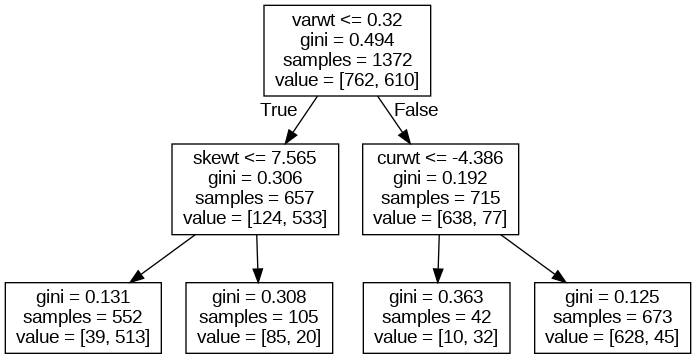

In [15]:
#@title **code** Visualize the resultant tree
#!sudo apt-get install graphviz
from sklearn.tree import export_graphviz
from IPython.display import Image
est.fit(X, y)
export_graphviz(est, out_file='tree_c.dot', feature_names=d.columns[:-1].values)
!dot -Tpng tree_c.dot > tree_c.png

Image(filename='tree_c.png')

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

**Exercise.**

- Train a classifier using only the **most important** features (by `feature_importances_`). Which model family performs best under this restriction?
- **Visualize** the fitted tree (**Graphviz** / `export_graphviz**) for your preferred configuration.
- **Sweep** decision-tree hyperparameters (e.g. depth, `min_samples_leaf`) and summarize the trade-off between **bias** and **variance**.


# **2. Random Forest Classifier (RFC)** <a name="eje2"></a>

A single tree can be **high-variance**: small changes in data or tie ordering may yield different splits. A **random forest** trains **many** trees on **bootstrap** samples of the data and **random** feature subsets at each split, then **aggregates** their votes (bagging + random subspaces). This typically **reduces variance** while preserving non-linear structure.

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/-/raw/master/imgs/randomforest.jpeg" width="500">


In [20]:
#@title **code:** working with a Random forest classifier
from sklearn.ensemble import RandomForestClassifier
est = RandomForestClassifier()
est.fit(X_train,y_train)
print(accuracy_score(est.predict(X_test), y_test))

0.9963636363636363


In [21]:
#@title **code** Implementing a Random forest classifier and a cross validation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

est = RandomForestClassifier()

s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True), scoring=make_scorer(accuracy_score))
print("accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))
s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True), scoring=tpr)
print("tpr      %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))
s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True), scoring=tnr)
print("tnr      %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))

accuracy 0.993 (+/- 0.00565)
tpr      0.997 (+/- 0.00610)
tnr      0.992 (+/- 0.00904)


<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

**Exercise.**

- Compute **precision** and **recall** on the **same** train–test split used above.
- Try other **RandomForest** settings—for example **`n_estimators`**—and relate behavior to **variance** and **runtime**.


# **3. Support Vector Machine (SVM)** <a name="eje3"></a>

**Support vector machines** are among the most widely used methods for **binary** (and multi-class) separation. The **examples** (as vectors in feature space) are used to identify a surface that best separates the classes.

- **Support vectors** are the training points that lie **closest** to the decision boundary (or to the margin); they **determine** the fitted separator, not the bulk of interior points.
- The **objective** is to **maximize the margin**—roughly, the distance between the separating surface and the nearest correctly classified samples of each class.

A schematic comparison of candidate hyperplanes:

- **H1:** does **not** separate the classes.
- **H2:** separates the classes but with a **small** margin (fragile generalization).
- **H3:** separates the classes with a **large** margin (the regime SVMs target).

**Margin:** the distance between the separating hyperplane and the nearest training points (per class, in the soft-margin formulation).

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/-/raw/master/imgs/svm_diagram.png" width="1000">


In [ ]:
#@title **code** SVM classification
from sklearn.svm import SVC
est = SVC()
est.fit(X_train,y_train)
print(accuracy_score(est.predict(X_test), y_test))

0.9927272727272727


In [ ]:
#@title **code** SVM classification and cross validation
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

est = SVC()

s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True), scoring=make_scorer(accuracy_score))
print("accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))
s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True), scoring=tpr)
print("tpr      %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))
s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True), scoring=tnr)
print("tnr      %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))

accuracy 0.997 (+/- 0.00669)
tpr      1.000 (+/- 0.00000)
tnr      0.995 (+/- 0.00835)


<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

**Exercise.**

- Compute **precision** and **recall** for the **SVM** on the train–test split.
- Explore **`kernel`**, **`gamma`**, and **`C`** (see `help(SVC)`) and relate fits to **margin** behavior and **overfitting**.


# 4. **Classification Boundaries** <a name="topic4"></a>

Each classifier **implicitly defines regions** in feature space: points are labeled according to which **side** of the learned surface they fall on. Different models induce different **geometries**—axis-aligned cuts for trees, smooth curves for kernel SVMs, etc.

The next cells use a **two-dimensional** synthetic dataset (`make_moons`) so you can **plot** predictions and **boundaries** side by side. The data are **regenerated** each time you run the generator unless you fix **`random_state`**.


In [ ]:
#@title **code**
%run -i code/utils.py
from sklearn import datasets
from sklearn.datasets import *


Graphviz already installed


0.02s
0.04s
0.02s


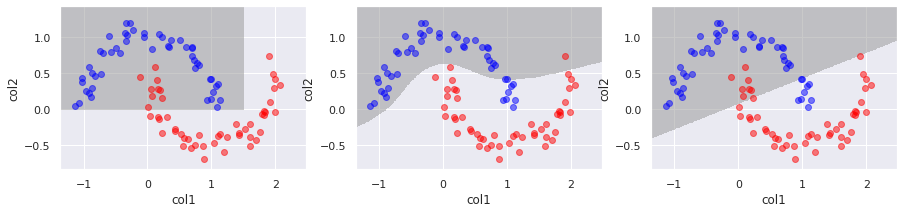

In [ ]:
#@title **code** computing boundaries
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import time

dt = DecisionTreeClassifier(max_depth=2)
sv = SVC(kernel="poly",  degree=3, gamma=2)
lr = LogisticRegression()

estimators = [ dt, sv, lr ]

X,y = make_moons(100, noise=0.1)

plt.figure(figsize=(15,3))
for i, estimator in enumerate(estimators):
    plt.subplot(1,3,i+1)
    t0 = time.time()
    estimator.fit(X,y)
    plot_2Ddata_with_boundary(estimator.predict, X,y)
    t1 = time.time()
    print( ('%.2fs' % (t1 - t0)))
    plt.xlabel("col1"); plt.ylabel("col2")


<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

**Exercise.**

- Vary **`max_depth`** on the **decision tree** (e.g. 1, 3, or larger) and observe how the **piecewise** boundary changes.
- Change **`kernel`**, **`degree`**, and **`gamma`** on **`SVC`** and relate flexibility to **margin** and **data noise**.
- Use **`help(DecisionTreeClassifier)`**, **`help(SVC)`**, and related utilities to list tunable parameters.


# 5. **Overfitting and Underfitting** <a name="topic5"></a>

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/-/raw/master/imgs/under-over-fitting.png" width="1000">

**Underfitting:** the model is too **simple** to capture the signal (high **bias**). **Overfitting:** the model **fits noise** or idiosyncrasies of the training sample (high **variance**, poor **generalization**). The plot above is a standard schematic relating **model capacity** to **error**.

The following cells increase **label noise** on `make_moons` and visualize train vs. test behavior with **`plot_train_test`**, then vary **SVM** hyperparameters.

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

**Reflection (before running).** For a very **noisy** two-moons dataset, what **shape** of boundary would you consider “natural”? What **test** accuracy would you **roughly** expect?


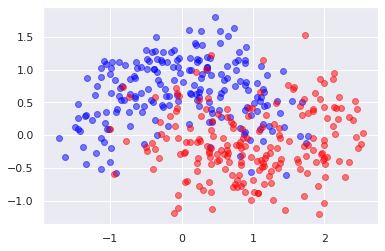

In [ ]:
#@title **code** Noise dataset
X,y = make_moons(400, noise=0.4)
plot_2Ddata_with_boundary(None, X,y)

In [ ]:

#@title **code** to plot
#@markdown we now use a 50/50 random split to train and to test
def plot_train_test(estimator, Xtr, Xts, ytr, yts, alpha=.5):
    estimator.fit(Xtr,ytr)
    plt.figure(figsize=(12,4))
    plt.subplot(121)
    plot_2Ddata_with_boundary(estimator.predict, Xtr,ytr, alpha=alpha)
    plt.title("TRAIN accuracy %.3f"%estimator.score(Xtr, ytr))
    plt.subplot(122)
    plot_2Ddata_with_boundary(estimator.predict, Xts,yts, alpha=alpha)
    plt.title("TEST accuracy %.3f"%estimator.score(Xts, yts))


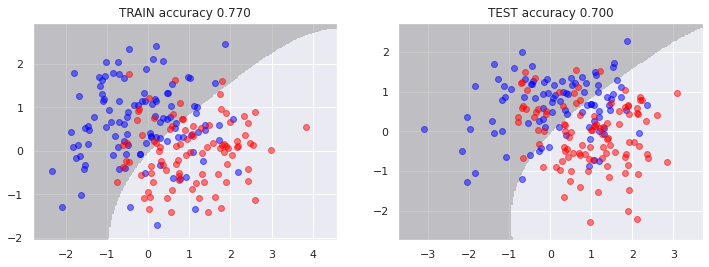

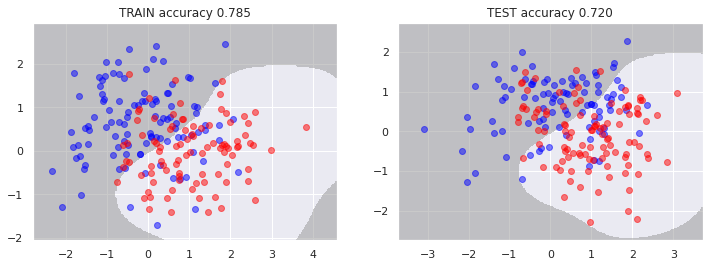

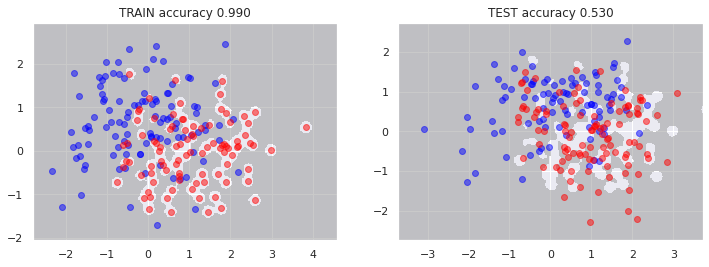

In [ ]:
#@title **code** SVM with different hyperparameters
from sklearn.model_selection import train_test_split
X,y = make_moons(400, noise=0.7)
Xtr, Xts, ytr, yts = train_test_split(X,y, test_size=.5)

plot_train_test(SVC(kernel="rbf",  gamma=.1), Xtr, Xts, ytr, yts)
plot_train_test(SVC(kernel="rbf",  gamma=1), Xtr, Xts, ytr, yts)
plot_train_test(SVC(kernel="rbf",  gamma=100), Xtr, Xts, ytr, yts)


<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

**Exercise.** Examine **underfitting** and **overfitting** on the **breast cancer** and **banknote authentication** datasets (reuse the plotting helpers where appropriate): compare **train vs. test** error as you change **capacity** or **regularization**.


# **References**

1. K-fold cross-validation (overview): [machinelearningmastery.com](https://machinelearningmastery.com/k-fold-cross-validation/)
2. Titanic competition (tabular classification example): [Kaggle](https://www.kaggle.com/c/titanic)
3. Sensitivity and specificity: [Wikipedia](https://en.wikipedia.org/wiki/Sensitivity_and_specificity)


---
<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/bannerThanks.jpg" alt="Drawing" style="width:700px;">
